<a href="https://colab.research.google.com/github/harirao3011/231FA04254-MLOps-Feast-SkillGap/blob/main/Curriculum_Industry_SkillGap_Full_ML_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Curriculum–Industry Skill Gap: Complete Machine Learning Pipeline

This notebook is built for the supplied **50,000-row curriculum–industry skill alignment dataset**.

It covers:

1. Load and inspect the dataset
2. Clean and validate the data
3. Create a binary placement target
4. Feature engineering
5. Train/test split with stratification
6. Numerical + categorical preprocessing
7. Multiple classification models
8. Class-imbalance handling
9. Accuracy, Precision, Recall, F1, ROC-AUC and confusion matrix
10. Model comparison and best-model selection
11. Final prediction for a sample student
12. Save the trained model
13. Create a Feast-ready Parquet feature dataset


## Important modelling decision

The original target has three classes:

- `Placed` = 48,915
- `Not Placed` = 1,084
- `Higher Studies` = 1

The `Higher Studies` class contains only one record, so a reliable 3-class model is not possible with this dataset. For this assignment, the target is converted to a **binary placement prediction**:

- `Placed` → `1`
- `Not Placed` or `Higher Studies` → `0`

Because the classes are highly imbalanced, the models use `class_weight='balanced'` where supported, and evaluation focuses on **Recall, F1 and ROC-AUC**, not accuracy alone.


In [1]:
# 1. Install required packages (run once if needed)
# Uncomment if your environment does not already have these packages.

# !pip install -U pandas numpy scikit-learn matplotlib seaborn pyarrow joblib


In [2]:
# 2. Imports and display settings

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.svm import LinearSVC

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42


In [4]:
# 3. Load dataset

DATA_PATH = "/content/CSE_Curriculum_Industry_Skill_Alignment_Dataset_50000.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"CSV not found at: {DATA_PATH}"
    )

df = pd.read_csv(DATA_PATH)

print("Using:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())

Using: /content/CSE_Curriculum_Industry_Skill_Alignment_Dataset_50000.csv
Shape: (50000, 28)


,Participant_ID,Age,Gender,Degree_Year,CGPA,Programming_Skill,DSA_Skill,DBMS_Skill,OS_Skill,CN_Skill,Web_Development,Cloud_Computing,AI_ML,Cybersecurity,DevOps,Communication,Teamwork,Problem_Solving,Critical_Thinking,Leadership,Internships,Projects,Certifications,Hackathons,Industry_Expectation,Employability_Score,Skill_Gap_Level,Placement_Status
0,CSE000001,25,Other,2027,8.38,41,70,55,63,52,33,96,79,21,85,67,42,41,45,47,1,1,8,1,92,79.18,Medium,Placed
1,CSE000002,26,Male,2027,6.49,77,70,91,35,55,74,53,45,29,37,88,61,46,45,68,0,6,5,4,78,81.31,Low,Placed
2,CSE000003,25,Female,2025,7.91,99,83,45,72,81,93,34,100,18,15,82,54,89,58,30,1,2,6,2,84,87.77,Low,Placed
3,CSE000004,26,Female,2027,7.17,53,69,84,44,56,88,41,30,69,58,57,99,80,84,91,1,6,0,1,71,81.80,Low,Placed
4,CSE000005,24,Female,2024,6.70,53,75,53,98,85,78,28,43,27,41,87,75,74,56,94,3,7,5,1,74,88.92,Low,Placed


In [5]:
# 4. Basic data inspection

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("missing"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["Placement_Status"].value_counts(dropna=False).to_frame("count"))


Column names:
['Participant_ID', 'Age', 'Gender', 'Degree_Year', 'CGPA', 'Programming_Skill', 'DSA_Skill', 'DBMS_Skill', 'OS_Skill', 'CN_Skill', 'Web_Development', 'Cloud_Computing', 'AI_ML', 'Cybersecurity', 'DevOps', 'Communication', 'Teamwork', 'Problem_Solving', 'Critical_Thinking', 'Leadership', 'Internships', 'Projects', 'Certifications', 'Hackathons', 'Industry_Expectation', 'Employability_Score', 'Skill_Gap_Level', 'Placement_Status']

Data types:


,dtype
Participant_ID,object
Age,int64
Gender,object
Degree_Year,int64
CGPA,float64
Programming_Skill,int64
DSA_Skill,int64
DBMS_Skill,int64
OS_Skill,int64
CN_Skill,int64



Missing values:


,missing
Participant_ID,0
Age,0
Gender,0
Degree_Year,0
CGPA,0
Programming_Skill,0
DSA_Skill,0
DBMS_Skill,0
OS_Skill,0
CN_Skill,0



Duplicate rows: 0

Target distribution:


,count
Placement_Status,
Placed,48915
Not Placed,1084
Higher Studies,1


## 5. Feature engineering

We do not use `Participant_ID` as a predictive feature.

We also do not use:

- `Placement_Status` as an input feature because it is the target.
- `Employability_Score` because it is already a derived score.
- `Skill_Gap_Level` because it is a derived categorical summary and can introduce target leakage.

Instead, we create reusable aggregate features from the raw skill/activity columns.


In [6]:
# 5. Feature engineering

technical_cols = [
    "Programming_Skill", "DSA_Skill", "DBMS_Skill", "OS_Skill", "CN_Skill",
    "Web_Development", "Cloud_Computing", "AI_ML",
    "Cybersecurity", "DevOps"
]

soft_cols = [
    "Communication", "Teamwork", "Problem_Solving",
    "Critical_Thinking", "Leadership"
]

experience_cols = [
    "Internships", "Projects", "Certifications", "Hackathons"
]

# Make sure the expected columns exist
required_cols = technical_cols + soft_cols + experience_cols + [
    "Age", "Gender", "Degree_Year", "CGPA", "Industry_Expectation",
    "Placement_Status", "Participant_ID"
]

missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing expected columns: {missing_required}")

# Numeric aggregates
df["technical_skill_avg"] = df[technical_cols].mean(axis=1)
df["soft_skill_avg"] = df[soft_cols].mean(axis=1)

# Normalize activity counts before combining them
for col in experience_cols:
    max_value = max(float(df[col].max()), 1.0)
    df[f"{col}_norm"] = 100.0 * df[col] / max_value

df["experience_index"] = (
    0.35 * df["Internships_norm"]
    + 0.30 * df["Projects_norm"]
    + 0.20 * df["Certifications_norm"]
    + 0.15 * df["Hackathons_norm"]
)

df["skill_strength_avg"] = (
    0.70 * df["technical_skill_avg"]
    + 0.30 * df["soft_skill_avg"]
)

df["industry_alignment_score"] = (
    0.70 * df["skill_strength_avg"]
    + 0.30 * df["Industry_Expectation"]
)

# Binary target
df["placement_target"] = (df["Placement_Status"] == "Placed").astype(int)

engineered_cols = [
    "technical_skill_avg",
    "soft_skill_avg",
    "experience_index",
    "skill_strength_avg",
    "industry_alignment_score"
]

display(df[engineered_cols + ["placement_target"]].head())


,technical_skill_avg,soft_skill_avg,experience_index,skill_strength_avg,industry_alignment_score,placement_target
0,59.5,48.4,33.916667,56.17,66.919,1
1,56.6,61.6,42.500000,58.10,64.070,1
2,64.0,62.6,36.166667,63.58,69.706,1
3,59.2,82.2,36.666667,66.10,67.570,1
4,58.1,77.2,73.750000,63.83,66.881,1


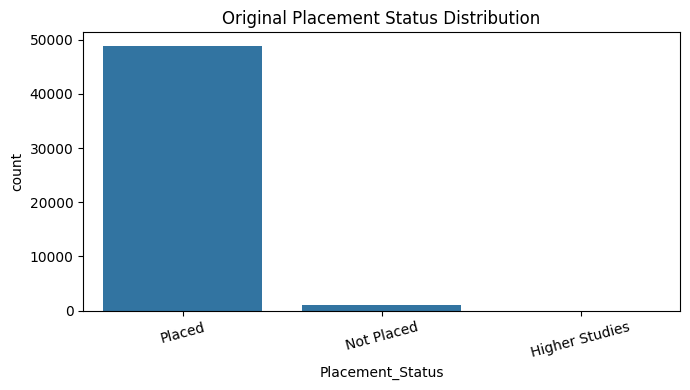

placement_target
1    48915
0     1085
Name: count, dtype: int64

Percentage distribution:
placement_target
1    97.83
0     2.17
Name: proportion, dtype: float64


In [7]:
# 6. Visualize target imbalance

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Placement_Status")
plt.title("Original Placement Status Distribution")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(df["placement_target"].value_counts())
print("\nPercentage distribution:")
print((df["placement_target"].value_counts(normalize=True) * 100).round(2))


## 7. Select the model features

The final model uses:

**Numerical**
- Age
- Degree_Year
- CGPA
- technical_skill_avg
- soft_skill_avg
- experience_index
- skill_strength_avg
- Industry_Expectation
- industry_alignment_score

**Categorical**
- Gender


In [8]:
# 7. Define X and y

feature_columns = [
    "Age",
    "Gender",
    "Degree_Year",
    "CGPA",
    "technical_skill_avg",
    "soft_skill_avg",
    "experience_index",
    "skill_strength_avg",
    "Industry_Expectation",
    "industry_alignment_score",
]

X = df[feature_columns].copy()
y = df["placement_target"].copy()

numeric_features = [
    "Age",
    "Degree_Year",
    "CGPA",
    "technical_skill_avg",
    "soft_skill_avg",
    "experience_index",
    "skill_strength_avg",
    "Industry_Expectation",
    "industry_alignment_score",
]

categorical_features = ["Gender"]

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())


X shape: (50000, 10)
y shape: (50000,)


,Age,Gender,Degree_Year,CGPA,technical_skill_avg,soft_skill_avg,experience_index,skill_strength_avg,Industry_Expectation,industry_alignment_score
0,25,Other,2027,8.38,59.5,48.4,33.916667,56.17,92,66.919
1,26,Male,2027,6.49,56.6,61.6,42.500000,58.10,78,64.070
2,25,Female,2025,7.91,64.0,62.6,36.166667,63.58,84,69.706
3,26,Female,2027,7.17,59.2,82.2,36.666667,66.10,71,67.570
4,24,Female,2024,6.70,58.1,77.2,73.750000,63.83,74,66.881


In [9]:
# 8. Train/test split
# Stratification preserves the target ratio in both sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\nTraining distribution:")
print(y_train.value_counts())
print("\nTesting distribution:")
print(y_test.value_counts())


X_train: (40000, 10)
X_test : (10000, 10)

Training distribution:
placement_target
1    39132
0      868
Name: count, dtype: int64

Testing distribution:
placement_target
1    9783
0     217
Name: count, dtype: int64


In [10]:
# 9. Preprocessing pipeline

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Keep the notebook compatible with both newer and older scikit-learn versions.
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


## 10. Models

The notebook compares several standard classification algorithms:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Extra Trees
5. Gradient Boosting
6. HistGradientBoosting
7. Linear SVM

Tree models do not need scaling conceptually, but keeping a common preprocessing pipeline makes the workflow consistent and reproducible.

For imbalanced data, `class_weight='balanced'` is used where supported.


In [11]:
# 10. Define models

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=3,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=3,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        C=1.0,
        random_state=RANDOM_STATE
    )
}

print("Models:", list(models.keys()))


Models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'HistGradientBoosting', 'Linear SVM']


In [12]:
# 11. Train and evaluate all models

results = []
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    print(f"Training: {name} ...")
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    # ROC-AUC requires a score/probability.
    if hasattr(pipeline, "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_score = pipeline.decision_function(X_test)

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_score)
    }

    results.append(result)
    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values(
    by=["F1", "ROC_AUC"],
    ascending=False
).reset_index(drop=True)

display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC_AUC": "{:.4f}"
}))


Training: Logistic Regression ...
Training: Decision Tree ...
Training: Random Forest ...
Training: Extra Trees ...
Training: Gradient Boosting ...
Training: HistGradientBoosting ...
Training: Linear SVM ...


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,HistGradientBoosting,0.9781,0.9830,0.9948,0.9889,0.9768
1,Gradient Boosting,0.9761,0.9829,0.9928,0.9878,0.9742
2,Random Forest,0.9671,0.9913,0.9750,0.9830,0.9738
3,Extra Trees,0.9428,0.9971,0.9443,0.9700,0.9739
4,Decision Tree,0.9344,0.9972,0.9356,0.9654,0.9224
5,Logistic Regression,0.9273,0.9993,0.9263,0.9614,0.9787
6,Linear SVM,0.9235,0.9994,0.9223,0.9593,0.9787


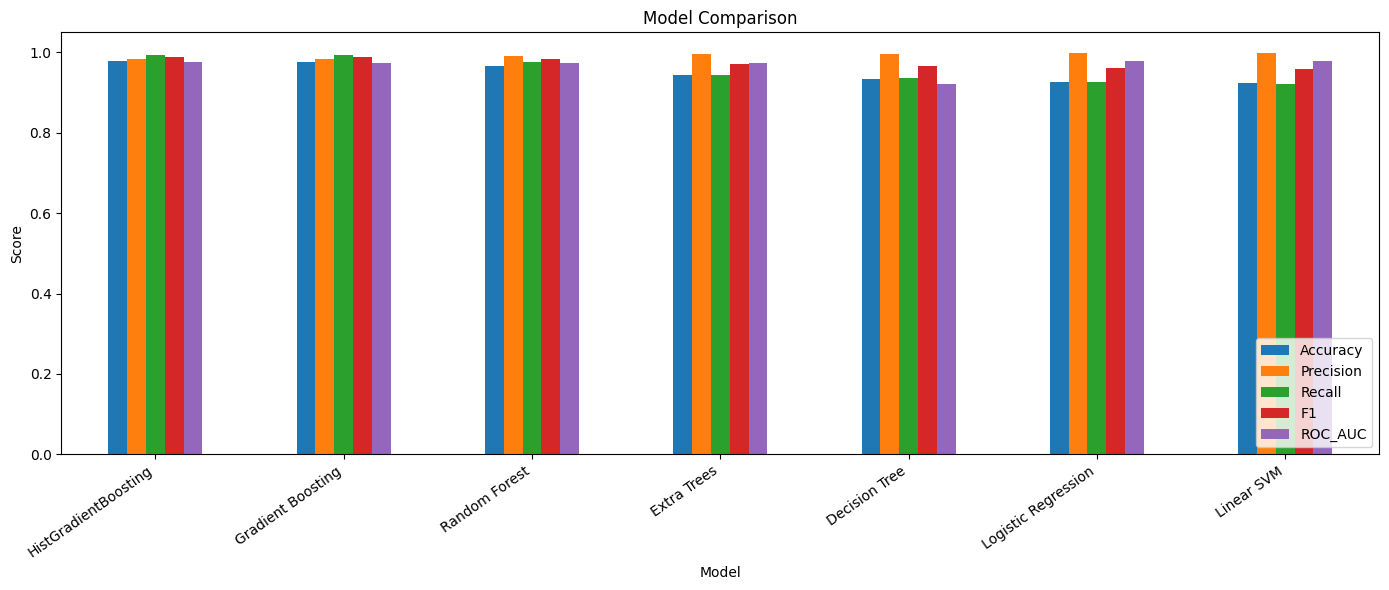

In [13]:
# 12. Compare models visually

plot_df = results_df.set_index("Model")[[
    "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"
]]

ax = plot_df.plot(kind="bar", figsize=(14, 6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=35, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [14]:
# 13. Select the best model
# F1 is used as the primary metric because the classes are imbalanced.

best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_models[best_model_name]

print("Best model:", best_model_name)
print(results_df.iloc[0])


Best model: HistGradientBoosting
Model        HistGradientBoosting
Accuracy                   0.9781
Precision                 0.98303
Recall                   0.994787
F1                       0.988874
ROC_AUC                   0.97677
Name: 0, dtype: object


                             precision    recall  f1-score   support

Not Placed / Higher Studies       0.49      0.23      0.31       217
                     Placed       0.98      0.99      0.99      9783

                   accuracy                           0.98     10000
                  macro avg       0.74      0.61      0.65     10000
               weighted avg       0.97      0.98      0.97     10000



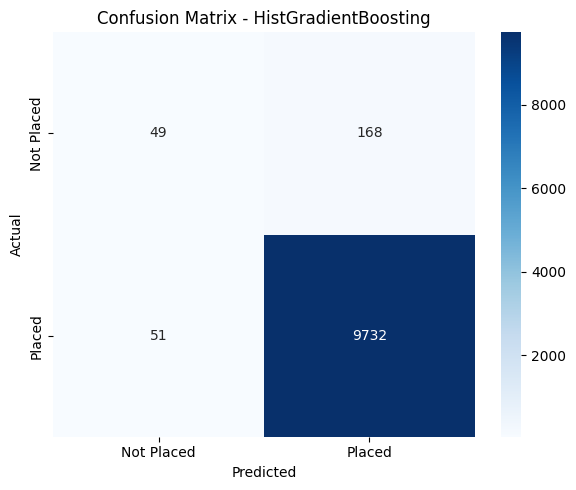

In [15]:
# 14. Detailed evaluation of the best model

best_pred = best_pipeline.predict(X_test)

if hasattr(best_pipeline, "predict_proba"):
    best_score = best_pipeline.predict_proba(X_test)[:, 1]
else:
    best_score = best_pipeline.decision_function(X_test)

print(classification_report(
    y_test,
    best_pred,
    target_names=["Not Placed / Higher Studies", "Placed"],
    zero_division=0
))

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()


<Figure size 700x600 with 0 Axes>

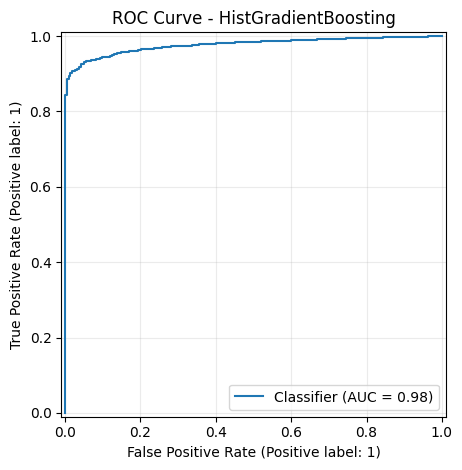

In [16]:
# 15. ROC curve of the best model

plt.figure(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, best_score)
plt.title(f"ROC Curve - {best_model_name}")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 16. Final student prediction

The next cell predicts the placement outcome for one student from the test set.

The model returns both:

- predicted class
- probability/score of placement


In [17]:
# 16. Final prediction example

sample_student = X_test.iloc[[0]].copy()

sample_prediction = best_pipeline.predict(sample_student)[0]

if hasattr(best_pipeline, "predict_proba"):
    placement_probability = best_pipeline.predict_proba(sample_student)[0, 1]
else:
    # Convert LinearSVC decision score to a rough 0-1 display score
    decision = best_pipeline.decision_function(sample_student)[0]
    placement_probability = 1 / (1 + np.exp(-decision))

print("Student input:")
display(sample_student)

print("Prediction:", "PLACED" if sample_prediction == 1 else "NOT PLACED")
print(f"Estimated placement probability: {placement_probability:.4f}")


Student input:


,Age,Gender,Degree_Year,CGPA,technical_skill_avg,soft_skill_avg,experience_index,skill_strength_avg,Industry_Expectation,industry_alignment_score
36460,21,Male,2026,5.71,63.0,68.8,46.166667,64.74,79,69.018


Prediction: PLACED
Estimated placement probability: 0.9987


In [18]:
# 17. Save the best ML pipeline

MODEL_PATH = "best_placement_model.joblib"
joblib.dump(best_pipeline, MODEL_PATH)

print("Saved:", MODEL_PATH)


Saved: best_placement_model.joblib


# 18. Create Feast-ready feature data

The following section creates the feature dataset that can be used by a Feast `FileSource`/`FeatureView`.

The target is kept in the Parquet file for historical training joins, but it should **not** be declared as a FeatureView feature.

Your original dataset has no event timestamp. For this classroom demonstration we create a deterministic timestamp. In a real system, use the real observation/event timestamp.


In [19]:
# 18. Create Feast-ready Parquet data

feast_df = df[
    [
        "Participant_ID",
        "Age",
        "Degree_Year",
        "CGPA",
        "Gender",
        "technical_skill_avg",
        "soft_skill_avg",
        "experience_index",
        "skill_strength_avg",
        "Industry_Expectation",
        "industry_alignment_score",
        "placement_target",
    ]
].copy()

feast_df["event_timestamp"] = (
    pd.Timestamp("2025-01-01")
    + pd.to_timedelta(np.arange(len(feast_df)), unit="s")
)

feast_df = feast_df[
    [
        "Participant_ID",
        "event_timestamp",
        "Age",
        "Degree_Year",
        "CGPA",
        "Gender",
        "technical_skill_avg",
        "soft_skill_avg",
        "experience_index",
        "skill_strength_avg",
        "Industry_Expectation",
        "industry_alignment_score",
        "placement_target",
    ]
]

FEAST_PATH = "skill_features.parquet"
feast_df.to_parquet(FEAST_PATH, index=False)

print("Saved Feast-ready feature file:", FEAST_PATH)
display(feast_df.head())


Saved Feast-ready feature file: skill_features.parquet


,Participant_ID,event_timestamp,Age,Degree_Year,CGPA,Gender,technical_skill_avg,soft_skill_avg,experience_index,skill_strength_avg,Industry_Expectation,industry_alignment_score,placement_target
0,CSE000001,2025-01-01 00:00:00,25,2027,8.38,Other,59.5,48.4,33.916667,56.17,92,66.919,1
1,CSE000002,2025-01-01 00:00:01,26,2027,6.49,Male,56.6,61.6,42.500000,58.10,78,64.070,1
2,CSE000003,2025-01-01 00:00:02,25,2025,7.91,Female,64.0,62.6,36.166667,63.58,84,69.706,1
3,CSE000004,2025-01-01 00:00:03,26,2027,7.17,Female,59.2,82.2,36.666667,66.10,71,67.570,1
4,CSE000005,2025-01-01 00:00:04,24,2024,6.70,Female,58.1,77.2,73.750000,63.83,74,66.881,1


In [20]:
# 19. Create a Feast FeatureView definition file

feature_definition = r'''
from datetime import timedelta

from feast import Entity, FeatureView, Field
from feast.infra.offline_stores.file_source import FileSource
from feast.types import Float32, Int64, String

skill_source = FileSource(
    name="skill_features_source",
    path="data/skill_features.parquet",
    timestamp_field="event_timestamp",
)

participant = Entity(
    name="participant_id",
    join_keys=["Participant_ID"],
    description="Unique student/participant identifier",
)

skill_gap_features = FeatureView(
    name="skill_gap_features",
    entities=[participant],
    ttl=timedelta(days=3650),
    schema=[
        Field(name="Age", dtype=Int64),
        Field(name="Degree_Year", dtype=Int64),
        Field(name="CGPA", dtype=Float32),
        Field(name="Gender", dtype=String),
        Field(name="technical_skill_avg", dtype=Float32),
        Field(name="soft_skill_avg", dtype=Float32),
        Field(name="experience_index", dtype=Float32),
        Field(name="skill_strength_avg", dtype=Float32),
        Field(name="Industry_Expectation", dtype=Float32),
        Field(name="industry_alignment_score", dtype=Float32),
    ],
    source=skill_source,
    online=True,
)
'''

with open("feature_definitions.py", "w", encoding="utf-8") as f:
    f.write(feature_definition)

os.makedirs("data", exist_ok=True)
feast_df.to_parquet("data/skill_features.parquet", index=False)

print("Created:")
print("  feature_definitions.py")
print("  data/skill_features.parquet")


Created:
  feature_definitions.py
  data/skill_features.parquet


In [21]:
# 20. Save model results for the README/report

results_df.to_csv("model_comparison.csv", index=False)

summary = {
    "dataset_rows": int(len(df)),
    "dataset_columns": int(df.shape[1]),
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "best_model": best_model_name,
    "accuracy": float(results_df.iloc[0]["Accuracy"]),
    "precision": float(results_df.iloc[0]["Precision"]),
    "recall": float(results_df.iloc[0]["Recall"]),
    "f1": float(results_df.iloc[0]["F1"]),
    "roc_auc": float(results_df.iloc[0]["ROC_AUC"])
}

pd.DataFrame([summary]).to_csv("best_model_summary.csv", index=False)

print(summary)


{'dataset_rows': 50000, 'dataset_columns': 38, 'train_rows': 40000, 'test_rows': 10000, 'best_model': 'HistGradientBoosting', 'accuracy': 0.9781, 'precision': 0.983030303030303, 'recall': 0.994786875191659, 'f1': 0.9888736473098613, 'roc_auc': 0.9767696337717408}


# 21. Final pipeline summary

```text
Original CSV
    ↓
Data Validation
    ↓
Binary Target Creation
    ↓
Feature Engineering
    ↓
Train/Test Split (80/20, stratified)
    ↓
ColumnTransformer
    ├── Numerical → Median Imputation → StandardScaler
    └── Categorical → Most-Frequent Imputation → OneHotEncoder
    ↓
Multiple ML Models
    ├── Logistic Regression
    ├── Decision Tree
    ├── Random Forest
    ├── Extra Trees
    ├── Gradient Boosting
    ├── HistGradientBoosting
    └── Linear SVM
    ↓
Evaluation
    ├── Accuracy
    ├── Precision
    ├── Recall
    ├── F1
    ├── ROC-AUC
    └── Confusion Matrix
    ↓
Best Model
    ↓
Final Prediction
    ↓
Saved Model + Feast-ready Parquet
```

## What to report in your assignment

Use the `model_comparison.csv` and `best_model_summary.csv` generated by the notebook. Report the **actual values produced on your machine**, rather than copying a fixed accuracy from an earlier run.

For this dataset, emphasize **F1, Recall and ROC-AUC** because the target is strongly imbalanced.
